# Permutation entropy

Approximate Entropy measures whether nearby amplitude patterns remain similar when extended
by one time step. Permutation Entropy attacks the problem from a different angle.

Instead of comparing values directly, it looks at the **ordinal pattern** inside short windows.
That makes it less sensitive to monotone amplitude transformations and often more robust when
the ordering structure matters more than the exact magnitude.

## Core idea

Take a short block such as `[2.1, 4.4, 3.0]`.

The values are not as important as the ranking:

- smallest value is at position 0,
- then position 2,
- largest value is at position 1.

So the ordinal pattern is `(0, 2, 1)`.

Permutation Entropy counts how often each pattern occurs. A highly regular signal uses only a
small subset of possible patterns. A more irregular signal uses many patterns with similar
frequencies.

In [1]:
from __future__ import annotations

from typing import Iterable, Sequence
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams["figure.figsize"] = (10, 4)


def to_1d_float_array(x: Sequence[float] | np.ndarray, *, name: str = "x") -> np.ndarray:
    """Validate and convert input to a 1D float NumPy array."""
    arr = np.asarray(x, dtype=float)
    if arr.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, got shape={arr.shape}.")
    if arr.size == 0:
        raise ValueError(f"{name} must contain at least one value.")
    if not np.isfinite(arr).all():
        raise ValueError(f"{name} contains NaN or infinite values.")
    return arr


def embed(series: Sequence[float] | np.ndarray, m: int) -> np.ndarray:
    """Return the delay-embedding matrix with lag 1 and dimension m."""
    x = to_1d_float_array(series)
    if not isinstance(m, int) or m < 1:
        raise ValueError("m must be a positive integer.")
    n = x.size
    if n <= m:
        raise ValueError(f"Need len(series) > m, got n={n}, m={m}.")
    return np.lib.stride_tricks.sliding_window_view(x, m)


def phi(series: Sequence[float] | np.ndarray, m: int, r: float) -> float:
    """Compute the ApEn phi_m quantity using the Chebyshev distance."""
    x = to_1d_float_array(series)
    if not np.isfinite(r) or r <= 0:
        raise ValueError("r must be a positive finite number.")

    patterns = embed(x, m)
    # Pairwise Chebyshev distance between all embedded vectors.
    distances = np.max(np.abs(patterns[:, None, :] - patterns[None, :, :]), axis=2)
    c_i = np.mean(distances <= r, axis=1)
    c_i = np.clip(c_i, 1e-12, None)
    return float(np.mean(np.log(c_i)))


def approximate_entropy(series: Sequence[float] | np.ndarray, m: int = 2, r: float | None = None) -> float:
    """Approximate Entropy (ApEn).

    Parameters
    ----------
    series:
        Input time series.
    m:
        Embedding dimension.
    r:
        Tolerance. If omitted, uses 0.2 * standard deviation of the series.
    """
    x = to_1d_float_array(series)
    if r is None:
        std = float(np.std(x, ddof=0))
        r = 0.2 * std if std > 0 else 0.2
    return phi(x, m, r) - phi(x, m + 1, r)


def sample_entropy(series: Sequence[float] | np.ndarray, m: int = 2, r: float | None = None) -> float:
    """Sample Entropy (SampEn) with Chebyshev distance."""
    x = to_1d_float_array(series)
    if r is None:
        std = float(np.std(x, ddof=0))
        r = 0.2 * std if std > 0 else 0.2
    if not np.isfinite(r) or r <= 0:
        raise ValueError("r must be a positive finite number.")

    def _count_matches(patterns: np.ndarray) -> float:
        distances = np.max(np.abs(patterns[:, None, :] - patterns[None, :, :]), axis=2)
        matches = (distances <= r).astype(float)
        np.fill_diagonal(matches, 0.0)
        return float(matches.sum())

    patterns_m = embed(x, m)
    patterns_m1 = embed(x, m + 1)

    b = _count_matches(patterns_m)
    a = _count_matches(patterns_m1)

    if a == 0.0 or b == 0.0:
        return float("inf")
    return float(-np.log(a / b))


def zscore(series: Sequence[float] | np.ndarray) -> np.ndarray:
    """Standardize a numeric series."""
    x = to_1d_float_array(series)
    std = float(np.std(x, ddof=0))
    if std == 0.0:
        return np.zeros_like(x)
    return (x - np.mean(x)) / std

In [2]:
from collections import Counter
from math import factorial


def ordinal_pattern(window: Sequence[float] | np.ndarray) -> tuple[int, ...]:
    """Return the stable rank order of a window.

    Stable sorting matters when ties occur. It ensures deterministic behaviour.
    """
    arr = to_1d_float_array(window)
    return tuple(np.argsort(arr, kind="mergesort"))


def permutation_entropy(
    series: Sequence[float] | np.ndarray,
    *,
    order: int = 3,
    normalize: bool = True,
) -> float:
    """Compute permutation entropy based on ordinal patterns."""
    x = to_1d_float_array(series)
    if not isinstance(order, int) or order < 2:
        raise ValueError("order must be an integer >= 2.")
    if x.size < order:
        raise ValueError("series is shorter than the requested order.")

    windows = np.lib.stride_tricks.sliding_window_view(x, order)
    counts: Counter[tuple[int, ...]] = Counter(ordinal_pattern(w) for w in windows)
    probs = np.array(list(counts.values()), dtype=float)
    probs /= probs.sum()

    entropy = float(-(probs * np.log(probs)).sum())
    if normalize:
        entropy /= math.log(factorial(order))
    return entropy


def rolling_permutation_entropy(
    series: Sequence[float] | np.ndarray,
    *,
    window: int,
    order: int = 3,
) -> pd.Series:
    """Rolling permutation entropy with right-edge indexing."""
    x = to_1d_float_array(series)
    if window <= order:
        raise ValueError("window must be strictly larger than order.")
    values: list[float] = [np.nan] * (window - 1)

    for end in range(window, x.size + 1):
        segment = x[end - window : end]
        values.append(permutation_entropy(segment, order=order, normalize=True))
    return pd.Series(values)

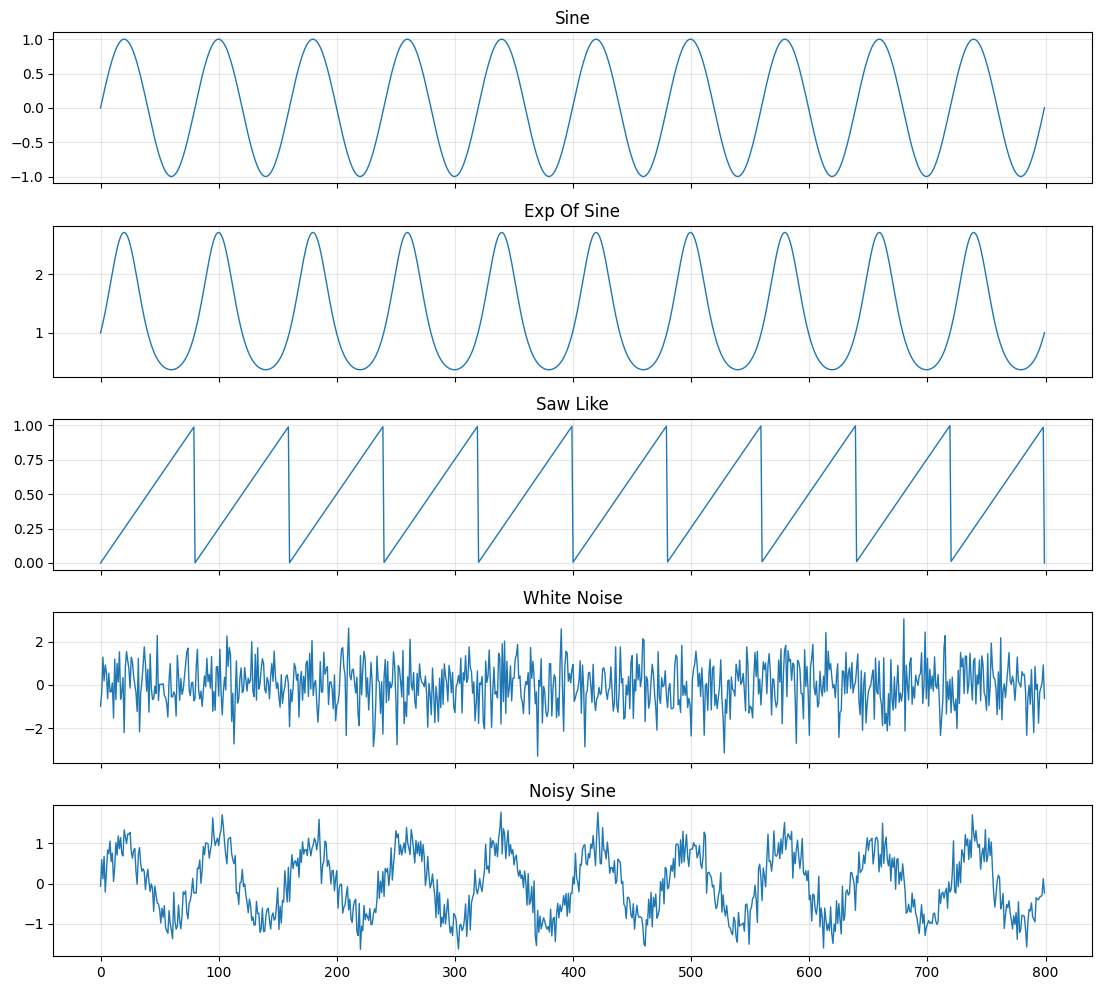

In [3]:
rng = np.random.default_rng(123)

n = 800
t = np.linspace(0.0, 20.0 * np.pi, n)

signals = {
    "sine": np.sin(t),
    "exp_of_sine": np.exp(np.sin(t)),  # same ordering, different amplitude geometry
    "saw_like": (t % (2 * np.pi)) / (2 * np.pi),
    "white_noise": rng.normal(size=n),
    "noisy_sine": np.sin(t) + 0.3 * rng.normal(size=n),
}

fig, axes = plt.subplots(len(signals), 1, figsize=(11, 10), sharex=True)
for ax, (name, values) in zip(axes, signals.items()):
    ax.plot(values, linewidth=1.0)
    ax.set_title(name.replace("_", " ").title())
    ax.grid(alpha=0.3)
plt.tight_layout()

## Inspecting ordinal patterns directly

In [4]:
toy = np.array([2.1, 4.4, 3.0, 1.5, 2.7, 2.8])
windows = np.lib.stride_tricks.sliding_window_view(toy, 3)

toy_patterns = pd.DataFrame(
    {
        "window": [list(map(float, w)) for w in windows],
        "ordinal_pattern": [ordinal_pattern(w) for w in windows],
    }
)
toy_patterns

,window,ordinal_pattern
0,"[2.1, 4.4, 3.0]","(0, 2, 1)"
1,"[4.4, 3.0, 1.5]","(2, 1, 0)"
2,"[3.0, 1.5, 2.7]","(1, 2, 0)"
3,"[1.5, 2.7, 2.8]","(0, 1, 2)"


In [5]:
rows: list[dict[str, float]] = []
for name, values in signals.items():
    rows.append(
        {
            "signal": name,
            "ApEn(m=2)": approximate_entropy(values, m=2),
            "PermutationEntropy(order=3)": permutation_entropy(values, order=3),
            "PermutationEntropy(order=5)": permutation_entropy(values, order=5),
        }
    )

comparison_df = pd.DataFrame(rows).sort_values("PermutationEntropy(order=5)")
comparison_df

,signal,ApEn(m=2),PermutationEntropy(order=3),PermutationEntropy(order=5)
2,saw_like,0.025166,0.071989,0.052723
0,sine,0.270803,0.461922,0.228830
1,exp_of_sine,0.232521,0.461922,0.228830
4,noisy_sine,1.349063,0.999504,0.981477
3,white_noise,1.581033,0.999331,0.984047


Notice the pair `sine` and `exp_of_sine`.

The second signal is a monotone transformation of the first one. The exact amplitudes changed,
but the relative ordering inside local windows is mostly preserved. Permutation Entropy reacts
much less to that transformation than amplitude-based measures often do.

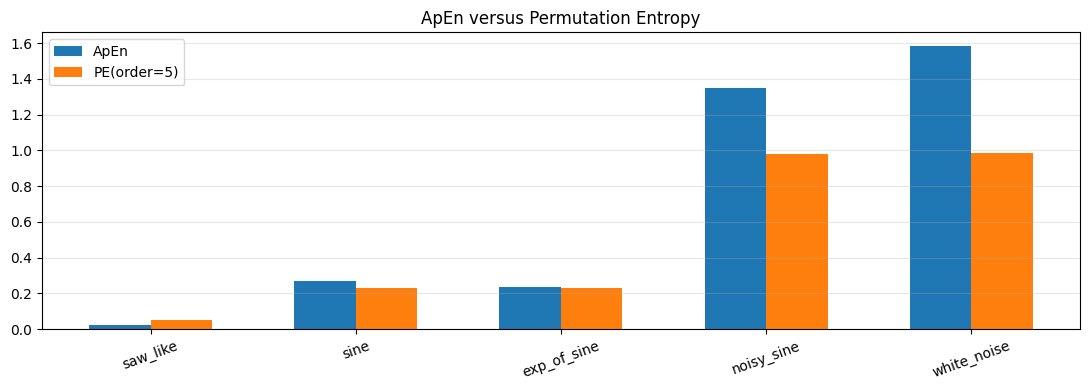

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
labels = comparison_df["signal"].tolist()
x_pos = np.arange(len(labels))
ax.bar(x_pos - 0.15, comparison_df["ApEn(m=2)"], width=0.3, label="ApEn")
ax.bar(x_pos + 0.15, comparison_df["PermutationEntropy(order=5)"], width=0.3, label="PE(order=5)")
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=20)
ax.set_title("ApEn versus Permutation Entropy")
ax.grid(alpha=0.3, axis="y")
ax.legend()
plt.tight_layout()

## Rolling permutation entropy for a regime-change signal

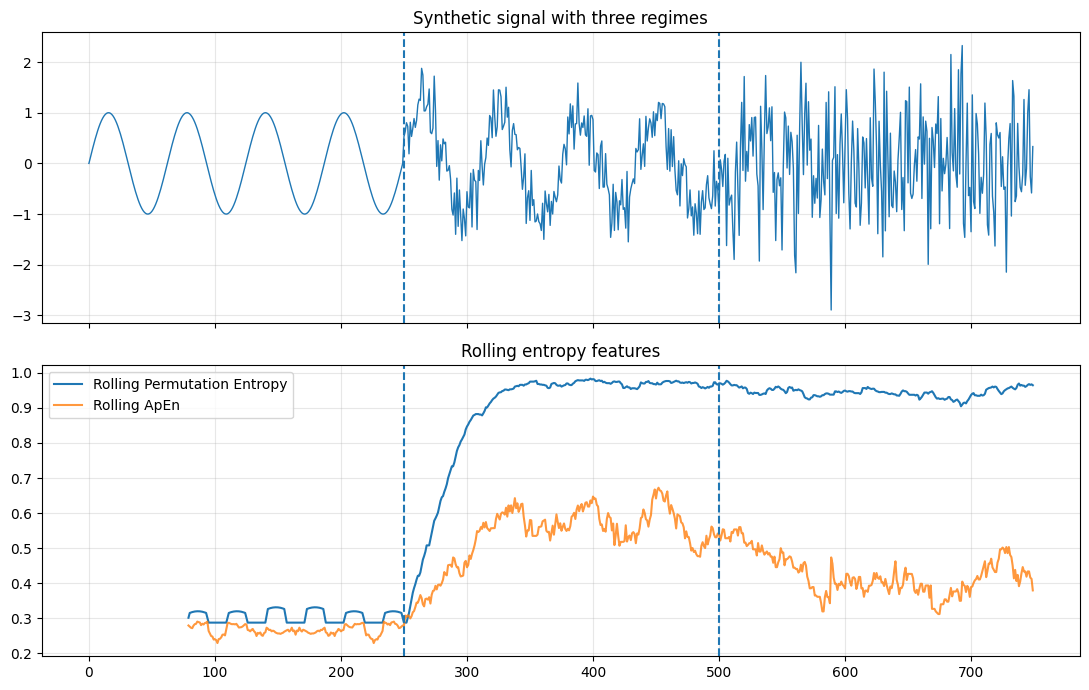

In [7]:
regime_signal = np.concatenate(
    [
        np.sin(np.linspace(0.0, 8.0 * np.pi, 250)),
        np.sin(np.linspace(0.0, 8.0 * np.pi, 250)) + 0.35 * rng.normal(size=250),
        rng.normal(size=250),
    ]
)

rolling_pe = rolling_permutation_entropy(regime_signal, window=80, order=4)
rolling_apen = pd.Series(
    [np.nan] * 79 + [
        approximate_entropy(regime_signal[i - 79 : i + 1], m=2)
        for i in range(79, regime_signal.size)
    ]
)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(regime_signal, linewidth=1.0)
axes[0].axvline(250, linestyle="--")
axes[0].axvline(500, linestyle="--")
axes[0].set_title("Synthetic signal with three regimes")
axes[0].grid(alpha=0.3)

axes[1].plot(rolling_pe, label="Rolling Permutation Entropy")
axes[1].plot(rolling_apen, label="Rolling ApEn", alpha=0.8)
axes[1].axvline(250, linestyle="--")
axes[1].axvline(500, linestyle="--")
axes[1].set_title("Rolling entropy features")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()

## When to prefer permutation entropy

Permutation Entropy is often a good choice when:

- the local ordering is more important than the exact amplitude,
- monotone transformations should not change the interpretation too much,
- you want an entropy notion that is simple and fast.

ApEn still has a different interpretation and remains valuable. The two features often work
well together in a regime-detection pipeline.